In [14]:
# config
samples = ["A1", "A2", "B2", "C2", "D1"]
gpu = False

In [2]:
import spatialdata as sd
import harpy as hp
import scanpy as sc
import scanorama

import torch.nn
import torch
import scvi
import numpy as np
import bbknn
import scib
import pandas as pd
from matplotlib.axes import Axes
import matplotlib.pyplot as plt

/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywi

In [3]:
print(f'CUDA available: {torch.cuda.is_available()}')

CUDA available: False


## Loading the data from zarr

In [4]:
sdata = sd.read_zarr("/scratch/leuven/357/vsc35768/spatial-transcriptomics/intermediate_results/20260107.zarr",
                         on_bad_files = "warn",)

no parent found for <ome_zarr.reader.Label object at 0x14b888be88c0>: None
no parent found for <ome_zarr.reader.Label object at 0x14b899a736b0>: None
no parent found for <ome_zarr.reader.Label object at 0x14b888a25dc0>: None
no parent found for <ome_zarr.reader.Label object at 0x14b888ba8410>: None
no parent found for <ome_zarr.reader.Label object at 0x14b888a7eba0>: None


In [5]:
sdata

SpatialData object, with associated Zarr store: /lustre1/scratch/357/vsc35768/spatial-transcriptomics/intermediate_results/20260107.zarr
├── Images
│     ├── 'A1_DAPI': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A1_clahe': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A1_min_max_filtered': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A2_DAPI': DataArray[cyx] (1, 10720, 17152)
│     ├── 'A2_clahe': DataArray[cyx] (1, 10720, 17152)
│     ├── 'A2_min_max_filtered': DataArray[cyx] (1, 10720, 17152)
│     ├── 'B2_DAPI': DataArray[cyx] (1, 10720, 19296)
│     ├── 'B2_clahe': DataArray[cyx] (1, 10720, 19296)
│     ├── 'B2_min_max_filtered': DataArray[cyx] (1, 10720, 19296)
│     ├── 'C2_DAPI': DataArray[cyx] (1, 12864, 21440)
│     ├── 'C2_clahe': DataArray[cyx] (1, 12864, 21440)
│     ├── 'C2_min_max_filtered': DataArray[cyx] (1, 12864, 21440)
│     ├── 'D1_DAPI': DataArray[cyx] (1, 12864, 19296)
│     ├── 'D1_clahe': DataArray[cyx] (1, 12864, 19296)
│     └── 'D1_min_max_filtered': DataArray[

# Single-cell analysis

## Transcript allocation

In [ ]:
for sample in samples:
    sdata = hp.tb.allocate(
        sdata = sdata,
        labels_layer = f"{sample}_segmentation_mask", 
        points_layer = f"{sample}_transcripts", 
        output_layer = f"{sample}_transcriptomics",
        update_shapes_layers = False,
        overwrite = True,
        to_coordinate_system = sample
    )

In [6]:
# qc of transcript allocation
def transcript_allocation_qc(sdata, sample):
    print(f"For {sample}:")
    print("Number of transcripts in points layer of sample: ", len(sdata.points[f"{sample}_transcripts"]))
    print("Number of transcripts assigned to cells: ", sdata.tables[f"{sample}_transcriptomics"].X.sum())
    print("Percentage of transcripts allocated: ", ((sdata.tables[f"{sample}_transcriptomics"].X.sum())/len(sdata.points[f"{sample}_transcripts"]))*100)

In [ ]:
for sample in samples:
    transcript_allocation_qc(
        sdata = sdata,
        sample = sample
    )

In [ ]:
sdata.tables["A1_transcriptomics"].X[:5, :5].toarray()

## Processing of cells

In [ ]:
# based on transcript data
for sample in samples:
    sdata = hp.tb.preprocess_transcriptomics(
        sdata = sdata,
        labels_layer = f"{sample}_segmentation_mask",
        table_layer = f"{sample}_transcriptomics",
        output_layer = f"{sample}_transcriptomics_preprocessed", # write results to a new slot, we could also write to the same slot (when passing overwrite==True).
        min_counts = 10,
        min_cells = 5,
        size_norm = True,
        highly_variable_genes = False,  # If True, will only retain highly variable genes. This can be used for transcriptome-wide methods.
        max_value_scale = 10, # The maximum value to which data will be scaled
        n_comps = 50, # Number of principal components to calculate.
        overwrite = True,
        update_shapes_layers = False,
    )

In [ ]:
# based on cell segmentation size
for sample in samples:
    sdata = hp.tb.filter_on_size(
        sdata = sdata,
        labels_layer = f"{sample}_segmentation_mask",
        table_layer = f"{sample}_transcriptomics_preprocessed",
        output_layer = f"{sample}_transcriptomics_filter",
        min_size = 500, # Minimum cell size
        max_size = None
        update_shapes_layers = True,
        overwrite = True
)

In [ ]:
hp.pl.plot_shapes(
    sdata,
    img_layer="D1_clahe",
    table_layer="D1_transcriptomics_preprocessed",
    column="total_counts",
    shapes_layer="D1_segmentation_mask_boundaries",
    crd=[6000, 10000, 2500, 6500],
    figsize=(8,8),
    to_coordinate_system = sample    
)

## Clustering

In [ ]:
# Leiden clustering
for sample in samples:
    sdata = hp.tb.leiden(
        sdata = sdata,
        labels_layer = f"{sample}_segmentation_mask",
        table_layer = f"{sample}_transcriptomics_filter",
        output_layer = f"{sample}_transcriptomics_clustered_res0.9",
        calculate_umap = True,
        calculate_neighbors = True,
        n_pcs = 17, 
        n_neighbors = 35,
        resolution = 0.9,
        rank_genes = True,
        key_added = "leiden",
        overwrite = True,
    )

In [ ]:
for sample in samples: 
    print(sample)
    sc.pl.umap(
        sdata.tables[f"{sample}_transcriptomics_clustered_res0.9"], 
        color = ["leiden"], 
        show = True)

In [ ]:
for sample in samples:
    print(sample)
    sc.pl.rank_genes_groups(
        sdata.tables[f"{sample}_transcriptomics_clustered_res0.9"], 
        n_genes = 12, 
        sharey = False, 
        show = True
    )

In [ ]:
for sample in samples:
    hp.pl.plot_shapes(
        sdata,
        img_layer=f"{sample}_clahe",
        table_layer=f"{sample}_transcriptomics_clustered_res0.9",
        column="leiden",
        shapes_layer=f"{sample}_segmentation_mask_boundaries",
        alpha=1.0,
        linewidth=0,
        cmap='tab20',
        # crd=[2000, 4000, 2000, 4000]
        to_coordinate_system = sample    
    )

In [ ]:
sdata

In [ ]:
sdata.tables["A1_transcriptomics_filter"]

## Data integration: baseline object

In [6]:
adatas = [
    sdata.tables["A1_transcriptomics_filter"],
    sdata.tables["A2_transcriptomics_filter"],
    sdata.tables["B2_transcriptomics_filter"],
    sdata.tables["C2_transcriptomics_filter"],
    sdata.tables["D1_transcriptomics_filter"],
]

adatas = [ad.copy() for ad in adatas]

for ad, s in zip(adatas, samples):
    # put raw counts in X
    ad.X = ad.layers["raw_counts"].copy()

    # removes per sample preprocessing flags 
    ad.uns.pop("log1p", None)
    ad.uns.pop("pca", None)
    ad.obsm.pop("X_pca", None)
    ad.varm.pop("PCs", None)
    ad.uns.pop("neighbors", None)
    ad.obsp.clear()

# concatenate into one object
adata_master = sc.concat(
    adatas,
    keys = samples,
    label = "sample_id",
    uns_merge = "unique",
    index_unique = None,
)

# Ensure no stale preprocessing flag survives the concat
adata_master.uns.pop("log1p", None)
adata_master.uns.pop("pca", None)
adata_master.obsm.pop("X_pca", None)
adata_master.varm.pop("PCs", None)

# Store raw counts explicitly (counts are currently in X)
adata_master.layers["raw_counts"] = adata_master.X.copy()

# Normalize + log (stored as X)
sc.pp.normalize_total(adata_master, target_sum=1e4)
sc.pp.log1p(adata_master)

# Store logcounts explicitly (for Scanorama/BBKNN etc.)
adata_master.layers["logcounts"] = adata_master.X.copy()

In [7]:
adata_master

AnnData object with n_obs × n_vars = 41569 × 96
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'sample_id'
    uns: 'spatialdata_attrs', 'log1p'
    obsm: 'spatial'
    layers: 'raw_counts', 'logcounts'

## Data integration: Unintegrated

In [8]:
adata_unin = adata_master.copy()
adata_unin.X = adata_unin.layers["logcounts"].copy()

In [ ]:
sc.pp.pca(adata_unin)
sc.pp.neighbors(adata_unin, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_unin)
sc.tl.leiden(adata_unin, key_added="clusters", resolution=0.2, directed=False)

In [ ]:
sc.pl.umap(adata_unin, color=["clusters", "sample_id"], palette = sc.pl.palettes.default_20)

## Data integration: Scanorama

In [11]:
adatas_split = [
    adata_master[adata_master.obs["sample_id"] == s].copy()
    for s in samples
]

In [ ]:
for ad in adatas_split:
    ad.X = ad.layers["logcounts"].copy()

adatas_cor = scanorama.correct_scanpy(adatas_split, return_dimred=True)

In [13]:
adata_scanorama = sc.concat(
    adatas_cor,
    keys=samples,
    label="sample_id",
    uns_merge="unique",
    index_unique=None,
)

In [14]:
sc.pp.neighbors(adata_scanorama, use_rep="X_scanorama")
sc.tl.umap(adata_scanorama)
sc.tl.leiden(adata_scanorama, key_added="clusters", resolution=0.2, directed=False)

In [ ]:
sc.pl.umap(adata_scanorama, color=["clusters", "sample_id"], palette = sc.pl.palettes.default_20)

## Data integration: scVI

In [8]:
adata_scvi = adata_master.copy()

In [9]:
scvi.model.SCVI.setup_anndata(adata_scvi, layer = "raw_counts", batch_key = "sample_id")

In [10]:
model_scvi = scvi.model.SCVI(adata_scvi)
model_scvi

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [11]:
model_scvi.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': 'raw_counts',
│   'batch_key': 'sample_id',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   5   │
│         n_cells          │ 41569 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │  96   │
└──────────────────────────┴───────┘

                Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location     ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │ adata.layers['raw_counts'] │
│    batch     │  adata.obs['_scvi_batch']  │
│    labels    │ adata.obs['_scvi_labels']  │
└──────────────┴────────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample_id'] │     A1     │          0          │
│                        │     A2     │          1          │
│                        │     B2     │          2          │
│                        │     C2     │          3          │
│                        │     D1     │          4          │
└────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [ ]:
# max_epochs_scvi = np.min([round((20000 / adata_scvi.n_obs) * 400), 400])
# max_epochs_scvi

In [15]:
if gpu == True:
    import os
    os.environ.pop('SLURM_NTASKS', None)
    os.environ.pop('SLURM_NTASKS_PER_NODE', None)
    torch.set_float32_matmul_precision("high")
    device_accelerator = "gpu"
else:
    device_accelerator = "cpu"

In [16]:
model_scvi.train(
    accelerator = device_accelerator,
    devices = 1,
    batch_size = 1024,
    max_epochs = 400,
    check_val_every_n_epoch = 1,
    early_stopping_monitor = "elbo_validation",
    early_stopping_patience = 30
)

/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/leuven/357/vsc35768/miniconda3/envs/st-analysi ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /data/leuven/357/vsc35768/miniconda3/envs/st-analysi ...
/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have man

Epoch 400/400: 100%|██████████| 400/400 [03:22<00:00,  2.00it/s, v_num=1, train_loss=68.7]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [03:22<00:00,  1.98it/s, v_num=1, train_loss=68.7]


In [ ]:
train_test_results = model_scvi.history["elbo_train"]
train_test_results["elbo_validation"] = model_scvi.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True) 
plt.show()

In [18]:
# saving the model
model_scvi.save("intermediate_results/scvi_model_20260112.pt", overwrite = True)

In [19]:
adata_scvi

AnnData object with n_obs × n_vars = 41569 × 96
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'sample_id', '_scvi_batch', '_scvi_labels'
    uns: 'spatialdata_attrs', 'log1p', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial'
    layers: 'raw_counts', 'logcounts'

In [20]:
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()

In [21]:
sc.pp.neighbors(adata_scvi, use_rep = "X_scVI")
sc.tl.umap(adata_scvi)
sc.tl.leiden(adata_scvi, key_added = "clusters", n_iterations = 1, flavor = "igraph", directed = False, resolution = 0.2)

In [ ]:
sc.pl.umap(adata_scvi, color=["clusters", "sample_id"], palette = sc.pl.palettes.default_20)

## Data integration: BBKNN

In [27]:
adata_bbknn = adata_master.copy()
adata_bbknn.X = adata_bbknn.layers["logcounts"].copy()

In [28]:
sc.pp.pca(adata_bbknn)
bbknn.bbknn(adata_bbknn, batch_key="sample_id")

In [29]:
sc.tl.umap(adata_bbknn)
sc.tl.leiden(adata_bbknn, key_added = "clusters", resolution = 0.2, directed=False)

In [ ]:
sc.pl.umap(adata_bbknn, color=["clusters", "sample_id"], palette = sc.pl.palettes.default_20)

## Benchmarking integration methods

In [ ]:
metrics_scvi = scib.metrics.metrics_fast(
    adata_unin, adata_scvi, "sample_id", label_key = "clusters", embed = "X_scVI"
)
metrics_bbknn = scib.metrics.metrics_fast(
    adata_unin, adata_bbknn, "sample_id", "clusters"
)
metrics_scanorama = scib.metrics.metrics_fast(
    adata_unin, adata_scanorama, "sample_id", label_key = "clusters", embed = "X_scanorama"
)

In [ ]:
metrics_scvi

In [36]:
import pandas as pd

In [ ]:
# Concatenate metrics results
metrics = pd.concat(
    [metrics_scvi, metrics_bbknn, metrics_scanorama],
    axis="columns",
)
# Set methods as column names
metrics = metrics.set_axis(
    ["scVI", "BBKNN", "Scanorama"], axis="columns"
)
# Select only the fast metrics
metrics = metrics.loc[
    [
        "ASW_label",
        "ASW_label/batch",
        "PCR_batch",
        "graph_conn",
        "hvg_overlap",
    ],
    :,
]
# Transpose so that metrics are columns and methods are rows
metrics = metrics.T
# Remove the HVG overlap metric because it's not relevant to embedding outputs
metrics = metrics.drop(columns=["hvg_overlap"])
metrics

In [ ]:
metrics.style.background_gradient(cmap="Blues")

In [ ]:
metrics_scaled = (metrics - metrics.min()) / (metrics.max() - metrics.min())
metrics_scaled.style.background_gradient(cmap="Blues")

In [44]:
import matplotlib.pyplot  as plt

In [ ]:
metrics_scaled["Batch"] = metrics_scaled[
    ["ASW_label/batch", "PCR_batch"]
].mean(axis=1)
metrics_scaled["Bio"] = metrics_scaled[["ASW_label"]].mean(
    axis=1
)
metrics_scaled.style.background_gradient(cmap="Blues")

In [ ]:
fig, ax = plt.subplots()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
metrics_scaled.plot.scatter(
    x="Batch",
    y="Bio",
    c=range(len(metrics_scaled)),
    ax=ax,
)

for k, v in metrics_scaled[["Batch", "Bio"]].iterrows():
    ax.annotate(
        k,
        v,
        xytext=(6, -3),
        textcoords="offset points",
        family="sans-serif",
        fontsize=12,
    )

In [ ]:
metrics_scaled["Overall"] = 0.4 * metrics_scaled["Batch"] + 0.6 * metrics_scaled["Bio"]
metrics_scaled.style.background_gradient(cmap="Blues")

In [ ]:
metrics_scaled.plot.bar(y="Overall")

## Using scVI batch corrected data

In [24]:
sc.tl.leiden(adata_scvi, key_added = "clusters", n_iterations = 1, flavor = "igraph", directed = False, resolution=0.4)

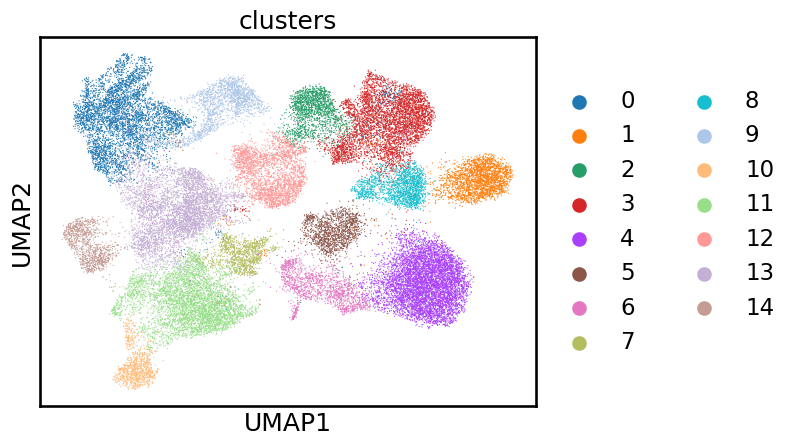

In [25]:
sc.pl.umap(
    adata_scvi, 
    color=[
        "clusters", 
        #"sample_id"
    ], 
    palette = sc.pl.palettes.default_20
)

In [26]:
adata_scvi

AnnData object with n_obs × n_vars = 41569 × 96
    obs: 'cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes', 'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'sample_id', '_scvi_batch', '_scvi_labels', 'clusters'
    uns: 'spatialdata_attrs', 'log1p', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'clusters', 'clusters_colors', 'sample_id_colors'
    obsm: 'spatial', 'X_scVI', 'X_umap'
    layers: 'raw_counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [27]:
# transfer cluster labels from adata_scvi to per sample AnnData from sdata using the obs_names
cluster_key = "clusters"

adatas_with_clusters = {}
for s in samples:
    # copy the original table
    ad = sdata.tables[f"{s}_transcriptomics_filter"].copy()

    # transfer clusters by aligning on obs_names
    ad.obs[cluster_key] = adata_scvi.obs.loc[ad.obs_names, cluster_key].astype("category")

    adatas_with_clusters[s] = ad

In [ ]:
adatas_with_clusters#["A1"].obs["clusters"]

In [29]:
# copying UMAP coordinates from adata_scvi to per sample AnnData 
name_to_idx = pd.Series(np.arange(adata_scvi.n_obs), index=adata_scvi.obs_names)

for s, ad in adatas_with_clusters.items():
    idx = name_to_idx.loc[ad.obs_names].values
    ad.obsm["X_umap_scvi"] = adata_scvi.obsm["X_umap"][idx, :]

In [ ]:
for s, ad in adatas_with_clusters.items():
    sc.pl.embedding(ad, basis="umap_scvi", color="clusters", title=f"{s} scVI clusters", cmap = "tab10")

In [31]:
cluster_key = "clusters"

for s in samples:
    # make a copy of the table
    ad = sdata.tables[f"{s}_transcriptomics_filter"].copy()

    # # make obs_names match
    # ad.obs_names = [f"{x}-{s}" for x in ad.obs_names]

    # add the clusters
    ad.obs[cluster_key] = adata_scvi.obs.loc[ad.obs_names, cluster_key].astype("category")

    # OPTIONAL: if you want the obs_names back without suffix in the stored table:
    # ad.obs_names = [x.replace(f"-{s}", "") for x in ad.obs_names]

    # overwrite or save as a new table
    sdata.tables[f"{s}_transcriptomics_filter_scvi_clusters"] = ad

In [32]:
sdata

SpatialData object, with associated Zarr store: /lustre1/scratch/357/vsc35768/spatial-transcriptomics/intermediate_results/20260107.zarr
├── Images
│     ├── 'A1_DAPI': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A1_clahe': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A1_min_max_filtered': DataArray[cyx] (1, 12864, 19296)
│     ├── 'A2_DAPI': DataArray[cyx] (1, 10720, 17152)
│     ├── 'A2_clahe': DataArray[cyx] (1, 10720, 17152)
│     ├── 'A2_min_max_filtered': DataArray[cyx] (1, 10720, 17152)
│     ├── 'B2_DAPI': DataArray[cyx] (1, 10720, 19296)
│     ├── 'B2_clahe': DataArray[cyx] (1, 10720, 19296)
│     ├── 'B2_min_max_filtered': DataArray[cyx] (1, 10720, 19296)
│     ├── 'C2_DAPI': DataArray[cyx] (1, 12864, 21440)
│     ├── 'C2_clahe': DataArray[cyx] (1, 12864, 21440)
│     ├── 'C2_min_max_filtered': DataArray[cyx] (1, 12864, 21440)
│     ├── 'D1_DAPI': DataArray[cyx] (1, 12864, 19296)
│     ├── 'D1_clahe': DataArray[cyx] (1, 12864, 19296)
│     └── 'D1_min_max_filtered': DataArray[

In [33]:
ad_saved = sdata.tables["A1_transcriptomics_filter_scvi_clusters"]
print(ad_saved.obs_names[:3].tolist())
print(ad_saved.obs.columns)
print(ad_saved.obs["clusters"].value_counts().head())

['33_A1_segmentation_mask_472e261b', '38_A1_segmentation_mask_472e261b', '39_A1_segmentation_mask_472e261b']
Index(['cell_ID', 'fov_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_2_genes',
       'pct_counts_in_top_5_genes', 'n_counts', 'shapeSize', 'clusters'],
      dtype='object')
clusters
4     1384
0     1162
13    1076
11    1026
3      958
Name: count, dtype: int64


/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/harpy/plot/_plot.py:687: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata_view.obs[column]):


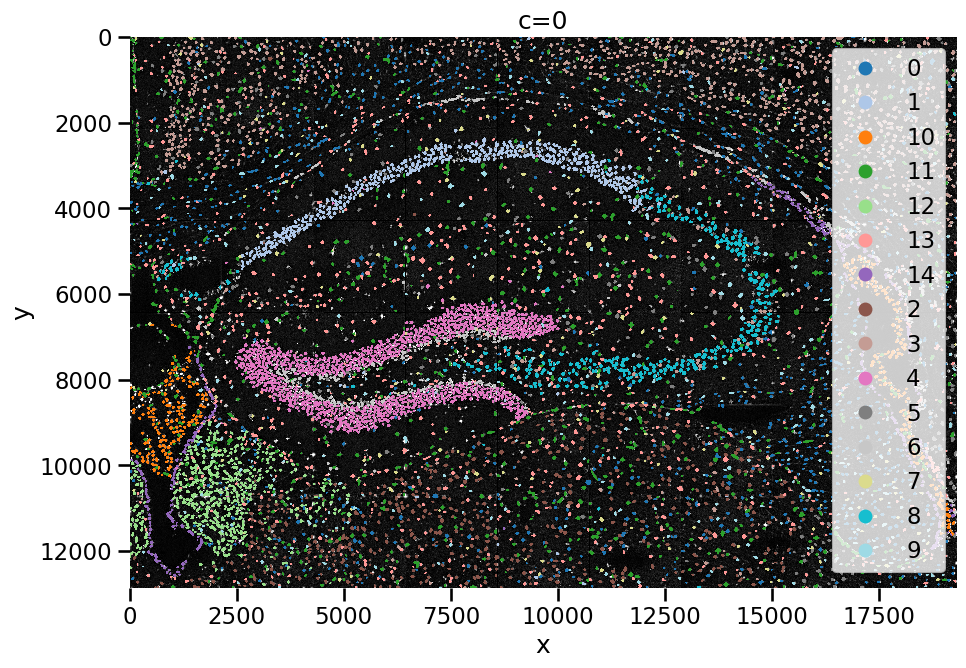

/data/leuven/357/vsc35768/miniconda3/envs/st-analysis/lib/python3.12/site-packages/harpy/plot/_plot.py:687: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata_view.obs[column]):


KeyboardInterrupt: 

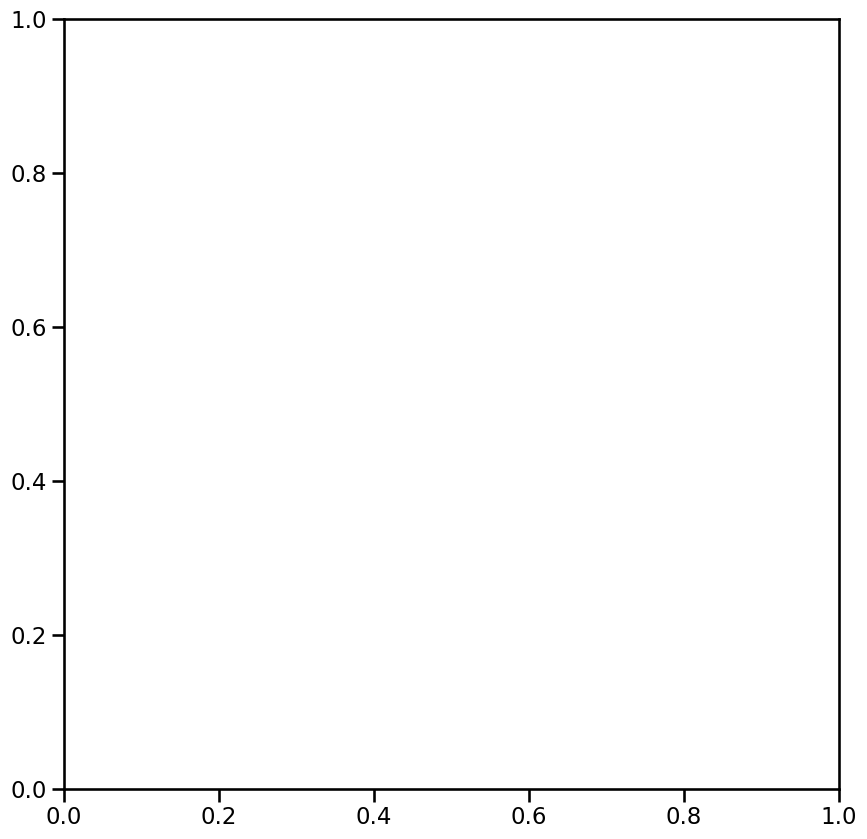

In [34]:
for sample in samples:
    hp.pl.plot_shapes(
        sdata,
        img_layer=f"{sample}_clahe",
        table_layer=f"{sample}_transcriptomics_filter_scvi_clusters",
        column="clusters",
        shapes_layer=f"{sample}_segmentation_mask_boundaries",
        alpha=1.0,
        linewidth=0,
        cmap='tab20',
        # crd=[2000, 4000, 2000, 4000]
        to_coordinate_system = sample    
    )

## Cell type annotation

In [35]:
adata = adata_scvi.copy()               
adata.X = adata.layers["logcounts"]

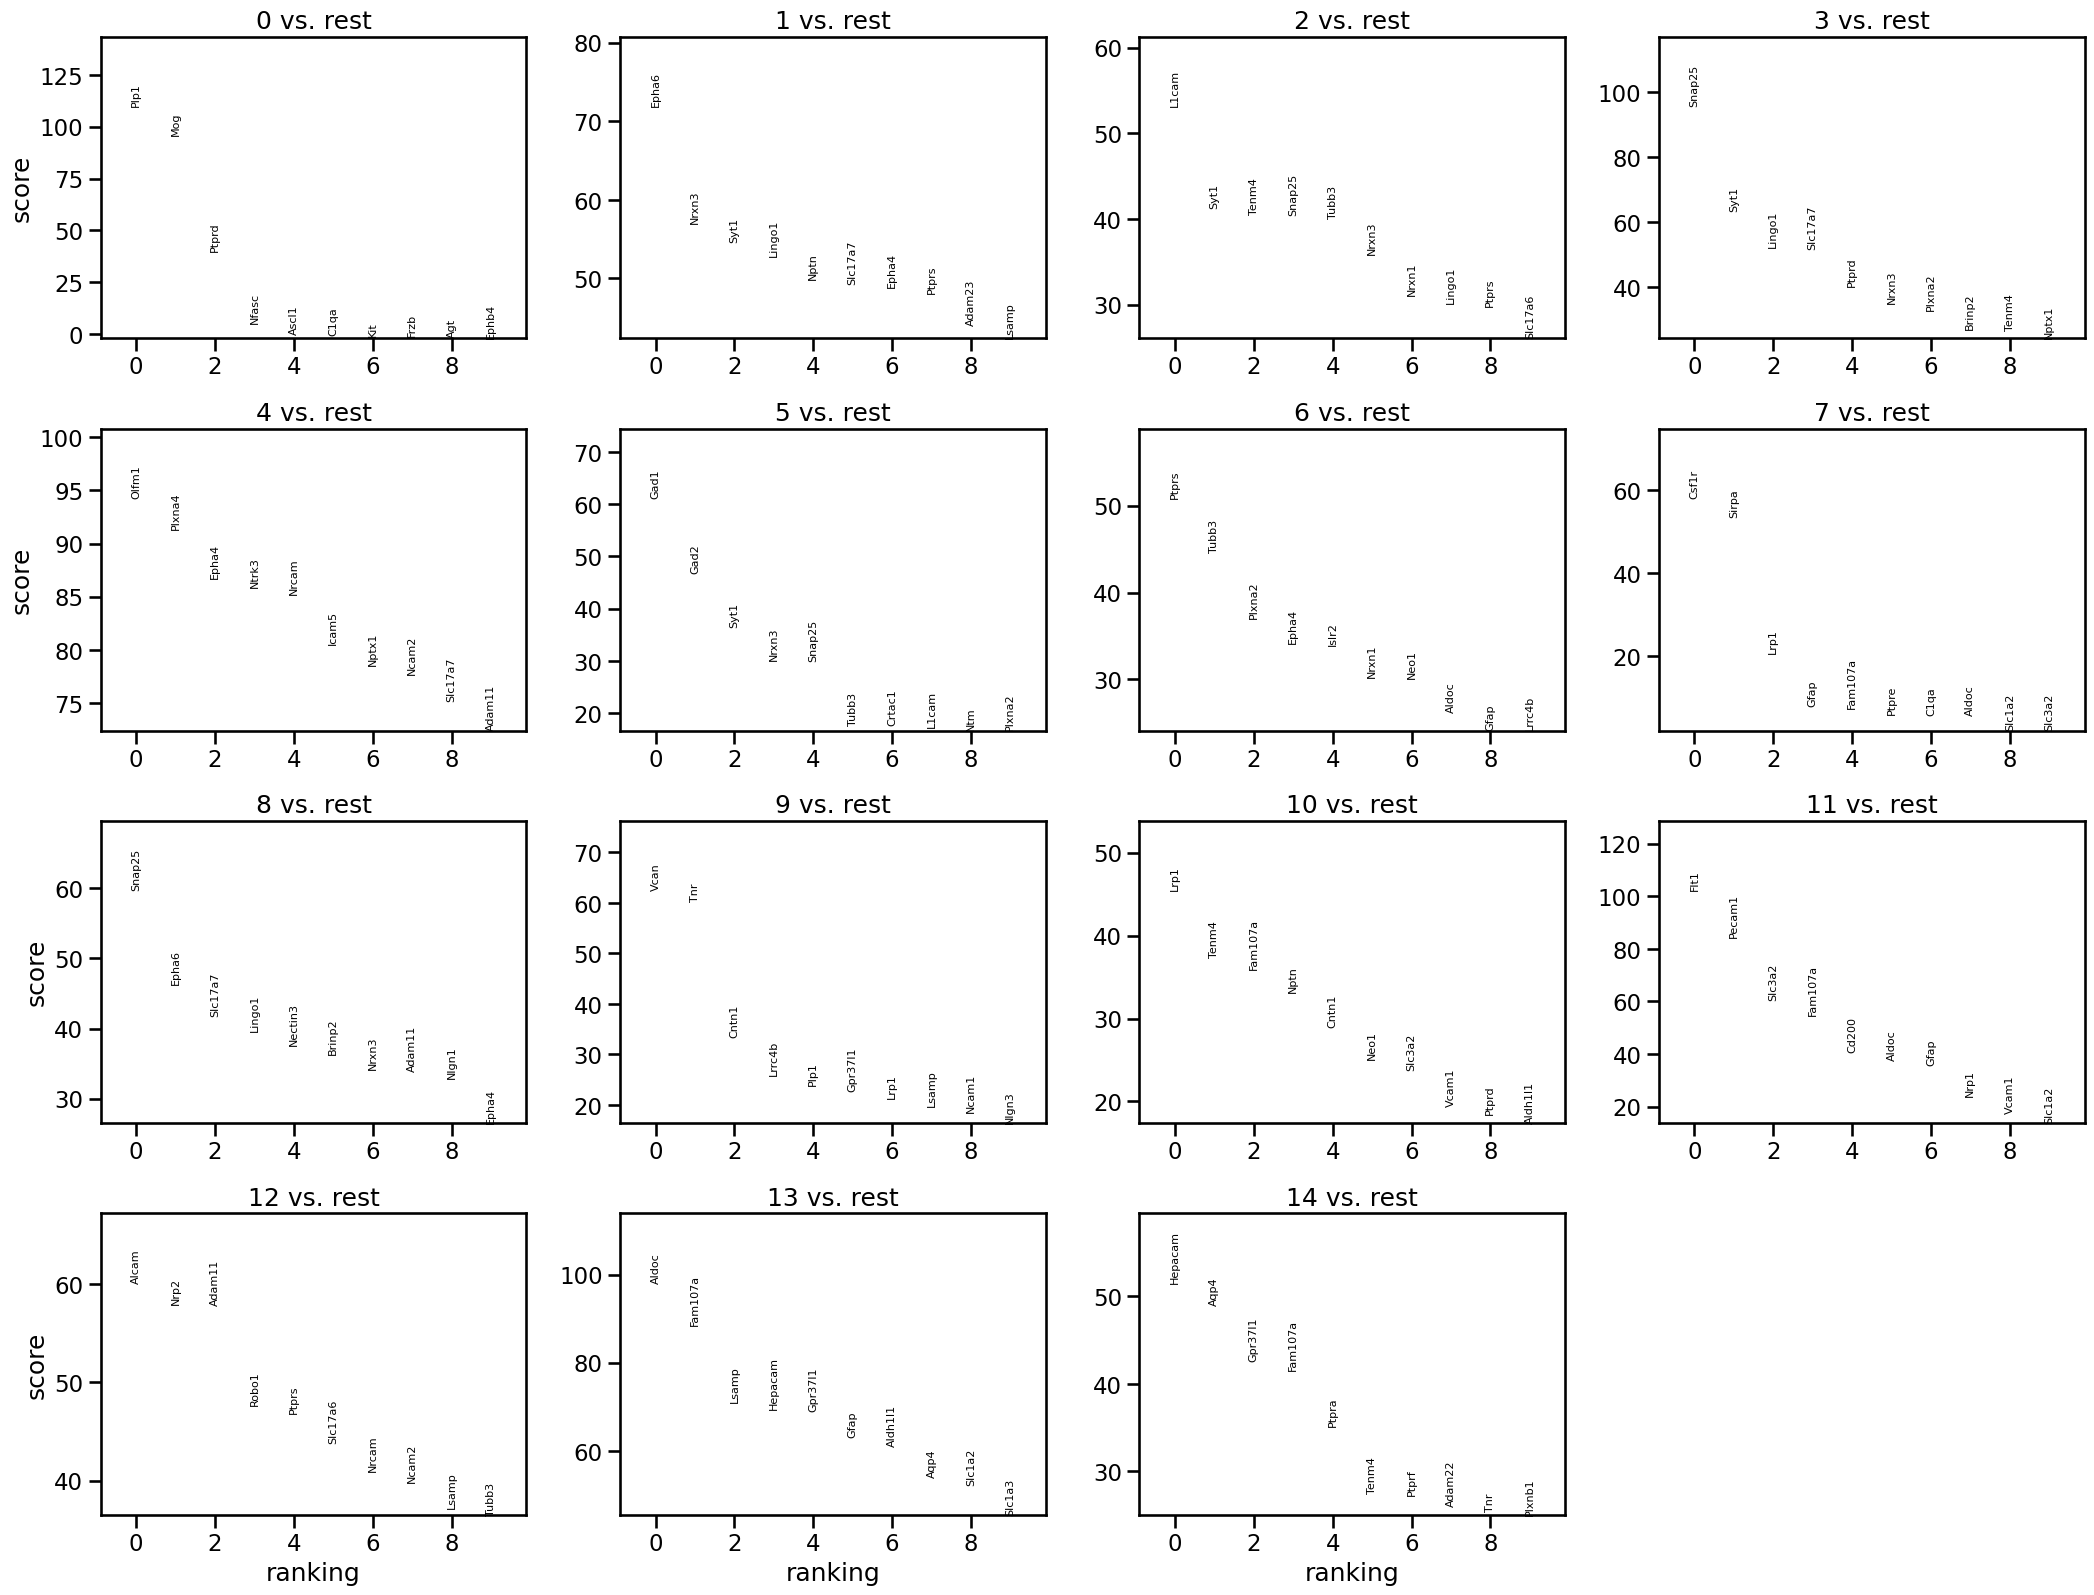

In [36]:
sc.tl.rank_genes_groups(
    adata,
    groupby="clusters",          # your cluster column
    method="wilcoxon",           # robust default
    pts=True,                    # fraction expressing per cluster
    use_raw=False                # because raw is counts here
)
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [32]:
cluster_to_celltype = {
    "0": "DG Granule Cells",
    "1": "Cortical Neurons",
    "2": "Oligodendrocytes",
    "3": "Endothelial Cells",
    "4": "Astrocytes Protoplasmic",
    "5": "Medial Habenula Neurons",
    "6": "CA1 Neurons",
    "7": "OPCs",
    "8": "CA2/CA3 Neurons",
    "9": "Thalamic Neurons",
    "10": "Microglia",
    "11": "DG Subgranular Layer",
    "12": "Inhibitory Neurons",
    "13": "Choriod Plexus Cells",
    "14": "Astrocytes Fibrous",
}

In [33]:
adata_scvi.obs["cell_type"] = (
    adata_scvi.obs["clusters"].astype(str).map(cluster_to_celltype)
)

adata_scvi.obs["cell_type"] = adata_scvi.obs["cell_type"].astype("category")

In [ ]:
adata_scvi

In [ ]:
sc.pl.umap(adata_scvi, color="cell_type", cmap = key)

In [36]:
adatas_with_celltype = {}

for s in samples:
    ad = sdata.tables[f"{s}_transcriptomics_filter"].copy()
    ad.obs_names = [f"{x}-{s}" for x in ad.obs_names]

    # bring over clusters and cell types
    ad.obs["clusters"] = adata_scvi.obs.loc[ad.obs_names, "clusters"].astype("category")
    ad.obs["cell_type"] = adata_scvi.obs.loc[ad.obs_names, "cell_type"].astype("category")

    adatas_with_celltype[s] = ad

In [ ]:
samples = ["A1", "A2", "B2", "C2", "D1"]

label_cols = ["cell_type", "clusters"] 

for s in samples:
    table_name = f"{s}_transcriptomics_filter"
    out_name   = f"{s}_transcriptomics_filter_annotated"

    ad = sdata.tables[table_name].copy()

    # make obs_names match the integrated object naming scheme
    ad.obs_names = [f"{x}-{s}" for x in ad.obs_names]

    # Safety check: ensure all cells exist in adata_scvi
    missing = ad.obs_names[~ad.obs_names.isin(adata_scvi.obs_names)]
    if len(missing) > 0:
        raise ValueError(
            f"{s}: {len(missing)} cells not found in adata_scvi.obs_names. "
            f"Example missing: {missing[:5].tolist()}"
        )

    # Transfer labels
    for col in label_cols:
        ad.obs[col] = adata_scvi.obs.loc[ad.obs_names, col].astype("category")

    # OPTIONAL: revert obs_names back to original (without "-A1" suffix)
    # This is often nicer for consistency with the rest of the SpatialData object.
    ad.obs_names = [x.rsplit(f"-{s}", 1)[0] for x in ad.obs_names]

    # Store as a NEW table in SpatialData
    sdata.tables[out_name] = ad

print("✅ Added annotated tables:")
print([f"{s}_transcriptomics_filter_annotated" for s in samples])


In [38]:
# assigning colors to each cell type
key = "cell_type"
# Make sure it's categorical and consistent order
adata_scvi.obs[key] = adata_scvi.obs[key].astype("category")

# Use one global order (important!)
celltypes = adata_scvi.obs[key].cat.categories.tolist()

# Build a palette (tab20 works up to 20 categories; for more use tab20 + tab20b/c)
cmap = plt.get_cmap("tab20")
palette = [cmap(i) for i in range(len(celltypes))]  # RGBA tuples

# Convert to HEX strings (scanpy prefers hex)
def rgba_to_hex(rgba):
    r, g, b, a = rgba
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))

palette_hex = [rgba_to_hex(c) for c in palette]

# Store palette in adata_scvi (scanpy convention: "<key>_colors")
adata_scvi.uns[f"{key}_colors"] = palette_hex

In [39]:
# Create a mapping: celltype -> color
ct2color = dict(zip(celltypes, palette_hex))

for s in samples:
    t = f"{s}_transcriptomics_filter_annotated"
    ad = sdata.tables[t]

    # Ensure categorical + same category order
    ad.obs[key] = ad.obs[key].astype("category")
    ad.obs[key] = ad.obs[key].cat.set_categories(celltypes)

    # Attach the exact same palette
    ad.uns[f"{key}_colors"] = [ct2color[ct] for ct in celltypes]

    # Put back (usually not necessary, but safe)
    sdata.tables[t] = ad

In [ ]:
for sample in samples:
    hp.pl.plot_shapes(
        sdata,
        img_layer=f"{sample}_clahe",
        table_layer=f"{sample}_transcriptomics_filter_annotated",
        column="cell_type",
        shapes_layer=f"{sample}_segmentation_mask_boundaries",
        alpha=1.0,
        linewidth=0,
        legend = False,
        # crd=[2000, 4000, 2000, 4000]
        to_coordinate_system = sample    
    )

In [ ]:
sdata

In [42]:
for s in samples:
    table_name = f"{s}_transcriptomics_filter_annotated"
    ad = sdata.tables[table_name]

    # Make a temporary version of obs_names that matches adata_scvi
    tmp_names = [f"{x}-{s}" for x in ad.obs_names]

    # Slice aggregated object to get UMAP coords
    umap_coords = adata_scvi[tmp_names, :].obsm["X_umap"].copy()

    # Store in this per-sample table
    ad.obsm["X_umap_scvi"] = umap_coords

    # (Optional) store as well in the original name
    # ad.obsm["X_umap"] = umap_coords

    # Write back to sdata (not strictly necessary if it's already the same object)
    sdata.tables[table_name] = ad

In [ ]:
for s in samples:
    ad = sdata.tables[f"{s}_transcriptomics_filter_annotated"]
    sc.pl.embedding(ad, basis="umap_scvi", color=key, title=f"{s} cell types (scVI UMAP)")

In [ ]:
# writing to zarr
sdata.write(f"/scratch/leuven/357/vsc35768/spatial-transcriptomics/intermediate_results/202601012.zarr", overwrite=True)

## Differential expression analysis

In [ ]:
adata_scvi.obs["cell_type"].value_counts()

In [ ]:
cell_type_1 = "Astrocytes Protoplasmic"
cell_idx1 = adata_scvi.obs["cell_type"] == cell_type_1
print(sum(cell_idx1), "cells of type", cell_type_1)

cell_type_2 = "DG Granule Cells"
cell_idx2 = adata_scvi.obs["cell_type"] == cell_type_2
print(sum(cell_idx2), "cells of type", cell_type_2)

In [ ]:
de_change = model_scvi.differential_expression(idx1=cell_idx1, idx2=cell_idx2, mode="change")
de_change.head(30)

In [ ]:
de_change_uniform = model_scvi.differential_expression(
    idx1=cell_idx1,  # we use the same cells as chosen before
    idx2=cell_idx2,
    weights="uniform",
    batch_correction=True,
    mode="change",
)
de_change_uniform.head(60)


In [ ]:
de_change_uniform["log10_pscore"] = np.log10(de_change_uniform["proba_not_de"])
de_change_uniform = de_change_uniform.join(adata.var, how="inner")
de_change_uniform.head(60)

In [ ]:
de_change_importance = model_scvi.differential_expression(
    idx1=cell_idx1,  # we use the same cells as chosen before
    idx2=cell_idx2,
    weights="importance",
    filter_outlier_cells=True,
    batch_correction=True,
    mode="change",
)

In [ ]:
de_change_importance["log10_pscore"] = np.log10(de_change_importance["proba_not_de"])
de_change_importance = de_change_importance.join(adata.var, how="inner")
de_change_importance.head(60)

In [77]:
import plotnine as p9

In [ ]:
de_comp = pd.concat(
    [
        de_change_importance.assign(flavor="importance"),
        de_change_uniform.assign(flavor="uniform"),
    ]
)

(
    p9.ggplot(de_comp, p9.aes("lfc_mean", "-log10_pscore"))
    + p9.geom_point(
    )  # Plot other genes with transparence
    + p9.labs(x="LFC mean", y="Significance score (higher is more significant)")
    + p9.facet_wrap("flavor")
)

In [ ]:
# Define genes you want to highlight
genes_of_interest = ["Gpr37l1", "Vcam1", "Hepacam", "Vcan", "Neo1", "Ephb4", "Ntm", "Alcam", "Cadm4", "Unc13b", "Lsamp"]  # Replace with your gene names

# Add column for FDR significance
de_comp["is_significant"] = (
    de_change_importance.assign(flavor="importance")["is_de_fdr_0.05"] | 
    de_change_uniform.assign(flavor="uniform")["is_de_fdr_0.05"]
)

# Add highlight column for genes of interest
de_comp["is_gene_of_interest"] = de_comp.index.isin(genes_of_interest)

# Create color categories
de_comp["color_group"] = "Not significant"
de_comp.loc[de_comp["is_significant"], "color_group"] = "Significant (FDR < 0.05)"
de_comp.loc[de_comp["is_gene_of_interest"], "color_group"] = "Gene of interest"

# Plot
(
    p9.ggplot(de_comp, p9.aes("lfc_mean", "-log10_pscore"))
    + p9.geom_point(p9.aes(color="color_group"), alpha=0.6, size=2)
    + p9.scale_color_manual(values={
        "Not significant": "lightgray",
        "Significant (FDR < 0.05)": "steelblue",
        "Gene of interest": "darkblue"
    })
    + p9.geom_text(
        data=de_comp[de_comp["is_gene_of_interest"]], 
        mapping=p9.aes(label=de_comp[de_comp["is_gene_of_interest"]].index),
        nudge_y=0.1,
        size=8
    )
    + p9.labs(x="LFC mean", y="Significance score (higher is more significant)")
    + p9.facet_wrap("flavor")
    + p9.theme_minimal()
)